# 2 — Clean and analyse a lake temperature profile

## Learning goals

At the end of this notebook, you will be able to:

1. recognize common problems in a raw cast;
2. retain the downcast and average repeated depths;
3. estimate the thermocline and seasonal thermocline;
4. interpret the centre of buoyancy;
5. calculate volume-weighted temperatures for lake layers;
6. recognize important edge cases.

The notebook starts with small visible arrays so every transformation can be understood before applying it to a file.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylake

from pylake import functions as fn

## A simple stratified profile

The upper water is warm, the deep water is cold, and the transition is rapid around 3–5 m. This is the typical structure of a stratified lake.

In [2]:
depth = np.array([0, 1, 2, 3, 4, 5, 6, 8, 10], dtype=float)
temperature = np.array([21.0, 20.8, 20.3, 18.8, 14.0, 10.8, 9.6, 8.9, 8.6])

profile = pd.DataFrame({"depth_m": depth, "temperature_c": temperature})
profile

,depth_m,temperature_c
0,0.0,21.0
1,1.0,20.8
2,2.0,20.3
3,3.0,18.8
4,4.0,14.0
5,5.0,10.8
6,6.0,9.6
7,8.0,8.9
8,10.0,8.6


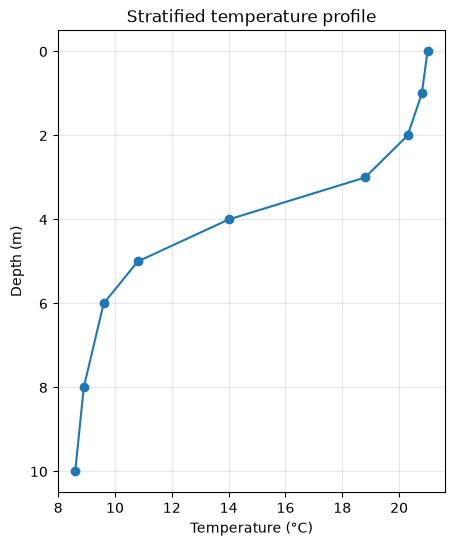

In [3]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(temperature, depth, marker="o")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Stratified temperature profile")
ax.grid(alpha=0.3)
plt.show()

## `depth_filter`: retain the downcast

A real instrument may remain near the surface, move upward briefly, and record an upcast after reaching maximum depth. `depth_filter` keeps the coherent descent. With `index=True`, it returns row positions that can be applied to every other sensor column.

In [4]:
raw_depth = np.array([0, 0.1, 0.05, 0.2, 0.8, 1.5, 1.4, 2.0, 3.0, 2.5])
raw_temperature = np.array([21.2, 21.1, 21.1, 21.0, 20.7, 19.8, 19.9, 18.0, 14.0, 15.2])

kept_rows = fn.depth_filter(raw_depth, run_length=2, index=True)
filtered = pd.DataFrame({
    "depth_m": raw_depth[kept_rows],
    "temperature_c": raw_temperature[kept_rows],
})

pd.DataFrame({"raw_depth_m": raw_depth, "raw_temperature_c": raw_temperature}), filtered

(   raw_depth_m  raw_temperature_c
 0         0.00               21.2
 1         0.10               21.1
 2         0.05               21.1
 3         0.20               21.0
 4         0.80               20.7
 5         1.50               19.8
 6         1.40               19.9
 7         2.00               18.0
 8         3.00               14.0
 9         2.50               15.2,
    depth_m  temperature_c
 0     0.05           21.1
 1     0.20           21.0
 2     0.80           20.7
 3     1.50           19.8
 4     2.00           18.0
 5     3.00           14.0)

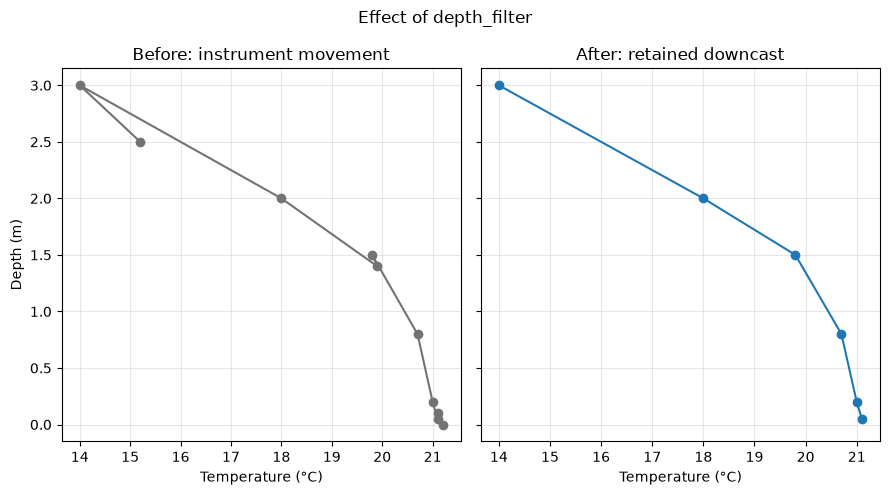

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

axes[0].plot(raw_temperature, raw_depth, marker="o", color="0.45")
axes[0].set_title("Before: instrument movement")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth (m)")

axes[1].plot(filtered["temperature_c"], filtered["depth_m"], marker="o", color="tab:blue")
axes[1].set_title("After: retained downcast")
axes[1].set_xlabel("Temperature (°C)")

for axis in axes:
    axis.invert_yaxis()
    axis.grid(alpha=0.3)

fig.suptitle("Effect of depth_filter")
fig.tight_layout()
plt.show()

### Interpretation

Returning indices is important: filtering only the depth vector would separate temperature, oxygen, and other measurements from their original rows.

## `depth_average`: merge repeated depths

Sensors may record several values at the same depth. `depth_average` returns unique depths and the mean finite measurement at each depth.

In [6]:
repeated_depth = np.array([1, 1, 2, 2, 3, 4, 4], dtype=float)
repeated_temperature = np.array([20, 22, 18, 20, 15, 11, 13], dtype=float)

average_depth, average_temperature = fn.depth_average(
    repeated_depth,
    repeated_temperature,
)

pd.DataFrame({"depth_m": average_depth, "mean_temperature_c": average_temperature})

,depth_m,mean_temperature_c
0,1.0,21.0
1,2.0,19.0
2,3.0,15.0
3,4.0,12.0


## Why density is used

The thermocline is estimated from the vertical change in **water density**, not directly from the largest temperature difference. Water density depends nonlinearly on temperature and can also depend on salinity.

In [7]:
density = np.asarray(pylake.water_density(temperature, S=0.2))

pd.DataFrame({
    "depth_m": depth,
    "temperature_c": temperature,
    "density_kg_m3": density,
}).head()

,depth_m,temperature_c,density_kg_m3
0,0.0,21.0,998.144243
1,1.0,20.8,998.187472
2,2.0,20.3,998.293733
3,3.0,18.8,998.596744
4,4.0,14.0,999.399158


## `thermocline`: locate the strongest density transition

The function returns two values: the estimated depth and the index of the density-gradient interval. `weighted=True` refines the location using neighbouring gradients. `weighted=False` returns the midpoint of the strongest interval.

In [8]:
weighted_depth, weighted_index = pylake.thermocline(
    temperature,
    depth,
    weighted=True,
)
midpoint_depth, midpoint_index = pylake.thermocline(
    temperature,
    depth,
    weighted=False,
)

pd.DataFrame({
    "method": ["weighted", "interval midpoint"],
    "thermocline_depth_m": [float(weighted_depth), float(midpoint_depth)],
    "gradient_interval_index": [int(weighted_index), int(midpoint_index)],
})

,method,thermocline_depth_m,gradient_interval_index
0,weighted,3.543149,4
1,interval midpoint,3.500000,3


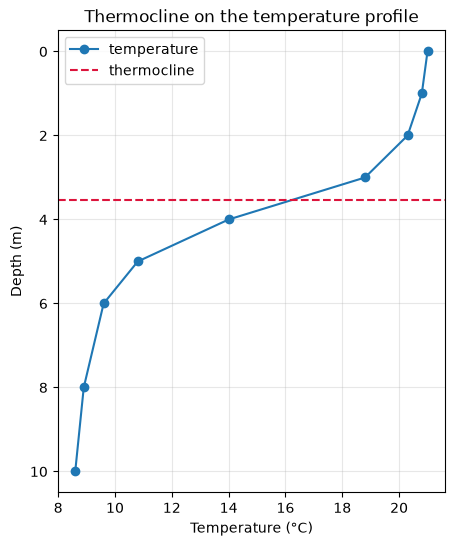

In [9]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(temperature, depth, marker="o", label="temperature")
ax.axhline(float(weighted_depth), color="crimson", linestyle="--", label="thermocline")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Thermocline on the temperature profile")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Interpretation

The dashed line crosses the rapid transition between warm surface water and cold deep water. The returned depth is an estimate between sensors, not a claim that a sensor existed at exactly that depth.

## `seasonal_thermocline`: choose among several gradients

Some profiles contain a shallow daily gradient and a deeper seasonal gradient. The seasonal function searches qualifying density-gradient peaks and can select the deeper structure. Smoothing is disabled here because this is one short demonstration profile.

In [10]:
seasonal_depth, seasonal_index = pylake.seasonal_thermocline(
    temperature,
    depth,
    seasonal_smoothed=False,
    weighted=True,
)

float(seasonal_depth), int(seasonal_index)

(3.543149174371563, 4)

## `center_buoyancy`: centre of stratification

This quantity is the depth-weighted centre of positive buoyancy frequency. It summarizes where stable stratification is concentrated. A completely uniform profile has no meaningful centre and returns `NaN`.

In [11]:
stratified_center = fn.center_buoyancy(temperature, depth)
uniform_center = fn.center_buoyancy(np.full(depth.size, 10.0), depth)

{"stratified_profile_m": stratified_center, "uniform_profile": uniform_center}

{'stratified_profile_m': np.float64(3.56160449373709), 'uniform_profile': nan}

## Bathymetry and volume-weighted layer means

A simple arithmetic mean treats a narrow deep layer and a wide surface layer equally. PyLake can weight measurements using lake area at successive depths.

- `bthD` contains bathymetric depths.
- `bthA` contains lake area at those depths.
- Area normally decreases toward the bottom.

In [12]:
bthD = np.array([0, 2, 4, 6, 8, 10], dtype=float)
bthA = np.array([100, 92, 78, 55, 25, 0], dtype=float)

pd.DataFrame({"bathymetry_depth_m": bthD, "lake_area_relative": bthA})

,bathymetry_depth_m,lake_area_relative
0,0.0,100.0
1,2.0,92.0
2,4.0,78.0
3,6.0,55.0
4,8.0,25.0
5,10.0,0.0


## Layer functions

`layer_temperature` calculates a volume-weighted mean between two boundaries. The convenience wrappers calculate the entire lake, the epilimnion above the metalimnion, and the hypolimnion below it.

In [13]:
meta_top = 3.0
meta_bottom = 5.0

layer_results = {
    "upper_0_to_3_m": fn.layer_temperature(0, meta_top, temperature, depth, bthA, bthD),
    "whole_lake": fn.whole_lake_temperature(temperature, depth, bthA, bthD),
    "epilimnion": fn.epi_temperature(temperature, depth, bthA, bthD, meta_top),
    "hypolimnion": fn.hypo_temperature(temperature, depth, bthA, bthD, meta_bottom),
}

pd.Series(layer_results, name="temperature_c")

upper_0_to_3_m    20.348940
whole_lake        15.932291
epilimnion        20.348940
hypolimnion        9.583065
Name: temperature_c, dtype: float64

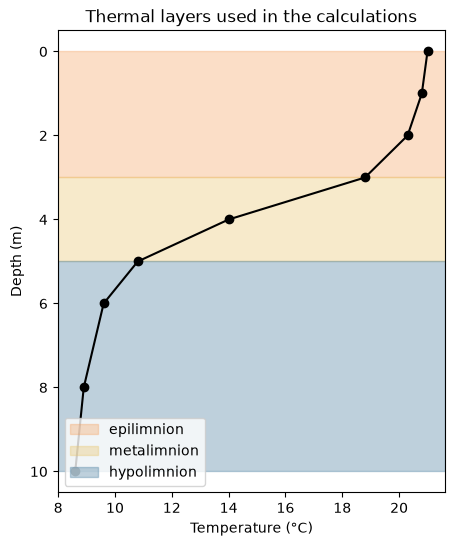

In [14]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(temperature, depth, color="black", marker="o", zorder=3)
ax.axhspan(0, meta_top, color="#f4a261", alpha=0.35, label="epilimnion")
ax.axhspan(meta_top, meta_bottom, color="#e9c46a", alpha=0.35, label="metalimnion")
ax.axhspan(meta_bottom, depth.max(), color="#457b9d", alpha=0.35, label="hypolimnion")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Thermal layers used in the calculations")
ax.legend(loc="lower left")
plt.show()

`layer_density` performs the same volume-weighted calculation after converting temperature and salinity into density.

In [15]:
fn.layer_density(
    0,
    meta_top,
    temperature,
    depth,
    bthA,
    bthD,
    sal=0.2,
)

np.float64(998.2805886068484)

## `ustar`: wind-driven water friction velocity

`ustar` converts wind speed into a friction velocity in water. It requires wind speed in m/s, wind measurement height in metres, and mean epilimnion density in kg/m³.

In [16]:
wind = np.array([2, 5, 10], dtype=float)
friction_velocity = fn.ustar(wind, wind_height=10, average_epi_density=998)

pd.DataFrame({"wind_m_s": wind, "ustar_m_s": friction_velocity})

,wind_m_s,ustar_m_s
0,2.0,0.002193
1,5.0,0.006715
2,10.0,0.013430


## Important edge cases

- Fewer than three measurements cannot define a reliable gradient profile.
- Repeated depths should be merged before thermocline analysis.
- A nearly uniform temperature profile is classified as mixed.
- Irregular depth spacing is supported.
- Layer boundaries must satisfy `top <= bottom`.
- Units must remain consistent.

In [17]:
edge_cases = {
    "three_points": pylake.thermocline([20, 10, 9], [1, 2, 3]),
    "uniform": pylake.thermocline([10, 10, 10, 10], [0, 1, 2, 3]),
    "irregular": pylake.thermocline(
        [21, 20.8, 20.4, 18, 12, 10, 9],
        [0, 0.4, 1.3, 2.7, 4.8, 7.5, 10],
    ),
}
edge_cases

{'three_points': (1.5, 0),
 'uniform': (nan, 0),
 'irregular': (3.2825505617189608, 3)}

## Check your understanding

1. Make the surface water 2 °C warmer and recalculate the thermocline.
2. Compare weighted and midpoint results on irregular depths.
3. Move `meta_top` from 3 m to 4 m and explain the epilimnion-temperature change.
4. Increase wind speed and describe what happens to `ustar`.

<details>
<summary><strong>What you should observe</strong></summary>

1. Changing surface temperature alters density gradients and can move the weighted estimate.
2. The midpoint stays at the centre of one sensor interval; weighting can place the estimate elsewhere inside it.
3. A deeper `meta_top` includes more cool water and will generally reduce the epilimnion mean.
4. `ustar` increases with wind speed because stronger wind transfers more momentum to the water.

</details>

## Take-away

Clean the cast first, inspect it visually, estimate stratification, and only then calculate layer properties. A numerical result should always be interpreted together with the profile and its units.